In [ ]:
#Credit card fraud detectn:

In [ ]:
#classificatn model -> accuracy_score if balanced data(balanced classes in label) else use precision, recall

In [ ]:
#workflow -> Read data -> pre-processing -> train_test_split -> Data analysis -> train_test_split -> train on logistic Regression and DecisionTree classifer model -> Evaluate

In [ ]:
#Logistic regression is used for binary classification. It uses sigmoid funct to predict category.
#see logistic_regression_vs_linear_regression.jpg

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv('creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

# pre-processing

In [7]:
# dataset infor -> col data type, non-null count 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
#statistical measures of data:

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,3.918649e-15,5.682686e-16,-8.761736e-15,2.811118e-15,-1.552103e-15,2.040130e-15,-1.698953e-15,-1.893285e-16,-3.147640e-15,...,1.473120e-16,8.042109e-16,5.282512e-16,4.456271e-15,1.426896e-15,1.701640e-15,-3.662252e-16,-1.217809e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
#missing val in each col of the data:

df.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [13]:
# distribution of legit transactions(0) & fraudulent transactions(1)
df['Class'].value_counts()


0    284315
1       492
Name: Class, dtype: int64

In [14]:
#insight: hugey imbalancd -> ispe train kiya toh mostly 0 hi predict krega model

<AxesSubplot:ylabel='Class'>

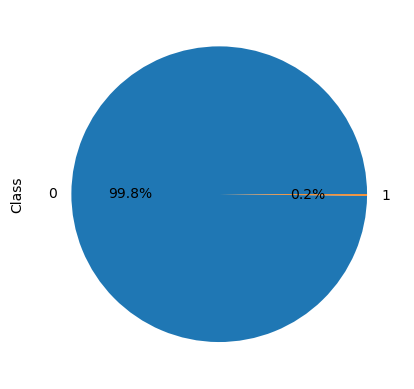

In [15]:
df['Class'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [ ]:
#Handle unbalanced data:

In [20]:
# separate the data for analysis
legit_df = df[df['Class']==0]

legit_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [26]:
fraud_df = df[df['Class']==1]

fraud_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


In [27]:
print(legit_df.shape)

print(fraud_df.shape)

(284315, 31)
(492, 31)


In [30]:
#get info, statistical measures of both derived data:

legit_df['Amount'].describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [31]:
fraud_df['Amount'].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [32]:
#insight: fraud_df ka mean Amoun is almost 50% highr than legit_df

In [33]:
#compare the val for both transaction

df.groupby('Class').mean()
#mean of all cols for both the val of Class

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [ ]:
#under-sampling:
#build a sample dataset containing similar uniform distribution of legit as well as fraud transaction.

In [35]:
# Number of Fraudulent Transactions --> 492

legit_sample = legit_df.sample(n=492)
legit_sample

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
94003,64686.0,1.368411,-0.348343,0.464618,-0.454287,-1.198089,-1.439657,-0.260534,-0.360692,-1.069235,...,-0.344811,-0.475863,0.103061,0.965197,0.225843,1.005505,-0.060654,0.011399,7.90,0
62896,50471.0,-0.750354,1.324904,1.080095,1.326729,-0.140160,0.039861,0.319783,0.512312,-0.517786,...,0.014454,0.286758,-0.083728,0.105724,-0.052168,-0.222504,0.304022,0.143393,17.96,0
282569,170994.0,0.223037,0.584685,-0.060649,-0.528546,-0.007327,0.150068,-0.295742,0.494123,0.257757,...,0.261230,0.728753,0.062053,0.096995,-0.729258,0.611482,-0.102737,-0.063575,10.90,0
197651,132113.0,1.836617,-0.972652,-1.318563,-0.129708,-0.761210,-1.471096,0.249034,-0.564969,-0.843176,...,-0.383698,-0.818044,0.194463,0.489407,-0.295991,0.430722,-0.092084,-0.028503,173.97,0
103799,68797.0,1.189669,-0.097028,0.571165,-0.033903,-0.735725,-0.979804,-0.065474,-0.243304,0.215980,...,-0.091170,-0.305006,0.040478,0.482069,0.138364,0.895295,-0.072490,0.020434,51.09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126763,78081.0,-1.554439,-0.901117,1.247196,0.519178,1.619378,-1.363273,-0.078951,0.157468,-0.182229,...,0.371366,0.487557,0.399152,0.036248,-0.468273,-0.603321,0.114682,0.222937,71.55,0
260565,159619.0,0.144668,1.066387,-0.476460,-0.593251,1.104601,-0.708617,1.018595,-0.143982,-0.159379,...,-0.343379,-0.806551,0.066722,0.392628,-0.362460,0.122558,0.226279,0.084555,4.67,0
67132,52383.0,-0.578261,-0.174819,2.156832,0.330512,-1.104805,0.227745,0.066893,0.272638,0.594445,...,0.001510,0.030802,0.369747,0.440444,-0.827153,1.014504,0.085668,0.155237,122.89,0
118420,75072.0,-0.565344,-0.614546,2.075204,0.757860,-1.508215,1.169547,0.701651,-0.204156,-1.361648,...,0.096736,0.542220,0.472003,-0.465534,-0.167293,-0.033250,-0.023389,-0.045657,330.00,0


In [36]:
#concatenante both df:

df_sample = pd.concat([legit_sample, fraud_df])   
#default = axis = 0: concatenates vertically (stacking rows) 


In [46]:
df_sample

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
94003,64686.0,1.368411,-0.348343,0.464618,-0.454287,-1.198089,-1.439657,-0.260534,-0.360692,-1.069235,...,-0.344811,-0.475863,0.103061,0.965197,0.225843,1.005505,-0.060654,0.011399,7.90,0
62896,50471.0,-0.750354,1.324904,1.080095,1.326729,-0.140160,0.039861,0.319783,0.512312,-0.517786,...,0.014454,0.286758,-0.083728,0.105724,-0.052168,-0.222504,0.304022,0.143393,17.96,0
282569,170994.0,0.223037,0.584685,-0.060649,-0.528546,-0.007327,0.150068,-0.295742,0.494123,0.257757,...,0.261230,0.728753,0.062053,0.096995,-0.729258,0.611482,-0.102737,-0.063575,10.90,0
197651,132113.0,1.836617,-0.972652,-1.318563,-0.129708,-0.761210,-1.471096,0.249034,-0.564969,-0.843176,...,-0.383698,-0.818044,0.194463,0.489407,-0.295991,0.430722,-0.092084,-0.028503,173.97,0
103799,68797.0,1.189669,-0.097028,0.571165,-0.033903,-0.735725,-0.979804,-0.065474,-0.243304,0.215980,...,-0.091170,-0.305006,0.040478,0.482069,0.138364,0.895295,-0.072490,0.020434,51.09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


<AxesSubplot:ylabel='Class'>

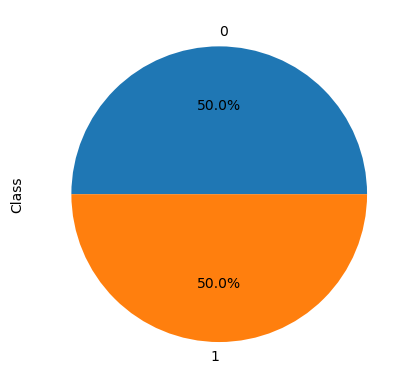

In [47]:
df_sample['Class'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [48]:
df_sample.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,95586.213415,-0.189645,0.177694,-0.042894,0.043612,-0.016932,0.080292,0.011110,-0.049287,-0.015557,...,0.048085,0.048492,-0.003730,-0.015449,-0.011236,-0.004313,-0.013864,0.006612,0.014894,99.776626
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [ ]:
#use this sample to train model

In [41]:
#split the label and i/p feature:

X = df_sample.drop(columns=['Class'])

y = df_sample['Class']

X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
94003,64686.0,1.368411,-0.348343,0.464618,-0.454287,-1.198089,-1.439657,-0.260534,-0.360692,-1.069235,...,-0.454178,-0.344811,-0.475863,0.103061,0.965197,0.225843,1.005505,-0.060654,0.011399,7.90
62896,50471.0,-0.750354,1.324904,1.080095,1.326729,-0.140160,0.039861,0.319783,0.512312,-0.517786,...,0.058535,0.014454,0.286758,-0.083728,0.105724,-0.052168,-0.222504,0.304022,0.143393,17.96
282569,170994.0,0.223037,0.584685,-0.060649,-0.528546,-0.007327,0.150068,-0.295742,0.494123,0.257757,...,-0.126942,0.261230,0.728753,0.062053,0.096995,-0.729258,0.611482,-0.102737,-0.063575,10.90
197651,132113.0,1.836617,-0.972652,-1.318563,-0.129708,-0.761210,-1.471096,0.249034,-0.564969,-0.843176,...,-0.223372,-0.383698,-0.818044,0.194463,0.489407,-0.295991,0.430722,-0.092084,-0.028503,173.97
103799,68797.0,1.189669,-0.097028,0.571165,-0.033903,-0.735725,-0.979804,-0.065474,-0.243304,0.215980,...,0.107647,-0.091170,-0.305006,0.040478,0.482069,0.138364,0.895295,-0.072490,0.020434,51.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,1.252967,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.226138,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.247968,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.306271,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00


In [42]:
y

94003     0
62896     0
282569    0
197651    0
103799    0
         ..
279863    1
280143    1
280149    1
281144    1
281674    1
Name: Class, Length: 984, dtype: int64

In [43]:
#split the data into training and testing:

from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)


In [44]:
X_train.shape

(787, 30)

In [49]:
#standardization -> mean is 0, std dev is 1 of standardized data
#same range of all features

from sklearn.preprocessing import StandardScaler


sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#fit_transform on X_train i.e learn parametres like mean, std dev and apply/transforms on training data
#ony transform on X_test  -> apply transformation.


In [50]:
X_train

array([[-0.96288979, -0.14774821,  0.41961013, ...,  0.68071971,
         0.8126392 , -0.3783438 ],
       [ 1.29191325,  0.36165265, -0.25239199, ..., -0.84799538,
        -1.61208319, -0.37754196],
       [ 1.14183331, -0.26148115, -1.11795306, ...,  2.70399967,
        -3.53413654, 13.32635766],
       ...,
       [-1.80061175, -0.12950731, -1.40571137, ..., -0.36151158,
        -0.0333484 ,  1.38650427],
       [-1.53444044, -0.58418099,  1.79604035, ...,  1.48863992,
         1.77407994, -0.37754196],
       [-0.04983789,  0.61998402, -0.50150856, ..., -0.1248163 ,
        -0.02626694,  0.13693811]])

# Model training

In [52]:
#c-1: Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

In [53]:
lr.fit(X_train,y_train)

LogisticRegression()

# Evaluate:

In [54]:
y_pred = lr.predict(X_test)

In [65]:
accuracy_score(y_test, y_pred)

0.9441624365482234

In [61]:
#c-2: DecisionTreeclassifier

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()


In [62]:
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [63]:
y_pred_dt = dt.predict(X_test)

In [64]:
accuracy_score(y_test, y_pred_dt)

0.9238578680203046

In [66]:
#so, accuracy_score(LogisticRegression) is slightly beter than accuracy_score(DecisionTree classifier).